In [6]:
# Student Placement Prediction and Career Success Analysis Using Data Science

#  Week 6 – Integrative Capstone Project

# Virtual Data Science with Python Trainee Program

In [7]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    silhouette_score
)
from sklearn.cluster import KMeans

In [8]:
df = pd.read_csv("/content/student_placement_career_success_dataset.csv")

print("Dataset loaded successfully!")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Dataset loaded successfully!
Number of rows: 25000
Number of columns: 44


In [9]:
print("First 5 rows:")
display(df.head())

First 5 rows:


,student_id,age,gender,state,city_tier,college_tier,branch,degree,cgpa,backlog_history,...,work_mode,salary_lpa,interview_rounds_cleared,offer_count,joining_delay_months,layoffs_risk_score,AI_tool_usage_frequency,prompt_engineering_skill,AI_fear_score,adaptability_score
0,STU00001,22,Male,Karnataka,1,2,Computer Science,MCA,6.71,3,...,Remote,17.36,4,1,2,62,55,55,19,81
1,STU00002,20,Male,Tamil Nadu,2,3,AI & DS,BTech,6.14,0,...,Onsite,18.22,3,3,0,55,66,52,54,76
2,STU00003,23,Female,Uttar Pradesh,3,2,Computer Science,BTech,7.11,0,...,Remote,22.08,1,3,1,79,69,67,49,34
3,STU00004,25,Male,Maharashtra,2,3,Civil,BTech,7.41,0,...,Remote,20.87,2,1,2,44,44,65,61,46
4,STU00005,25,Female,West Bengal,3,3,Civil,BE,8.29,0,...,Onsite,20.57,5,3,5,23,57,67,71,44


In [10]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 44 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  25000 non-null  object 
 1   age                         25000 non-null  int64  
 2   gender                      25000 non-null  object 
 3   state                       25000 non-null  object 
 4   city_tier                   25000 non-null  int64  
 5   college_tier                25000 non-null  int64  
 6   branch                      25000 non-null  object 
 7   degree                      25000 non-null  object 
 8   cgpa                        25000 non-null  float64
 9   backlog_history             25000 non-null  int64  
 10  attendance_percentage       25000 non-null  float64
 11  primary_language            25000 non-null  object 
 12  DSA_problems_solved         25000 non-null  int64  
 13  GitHub_rep

In [11]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
student_id                      0
age                             0
gender                          0
state                           0
city_tier                       0
college_tier                    0
branch                          0
degree                          0
cgpa                            0
backlog_history                 0
attendance_percentage           0
primary_language                0
DSA_problems_solved             0
GitHub_repos                  500
hackathons_participated         0
development_projects_count      0
AI_ML_projects                  0
internships_completed           0
resume_score                    0
communication_skills            0
aptitude_score                  0
mock_interview_score          500
sleep_hours                   500
screen_time                     0
gaming_hours                    0
study_hours_daily               0
stress_level                    0
burnout_score                   0
gym_frequency    

In [12]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [13]:
print("Column names:")
for i, col in enumerate(df.columns, 1):
    print(i, col)

Column names:
1 student_id
2 age
3 gender
4 state
5 city_tier
6 college_tier
7 branch
8 degree
9 cgpa
10 backlog_history
11 attendance_percentage
12 primary_language
13 DSA_problems_solved
14 GitHub_repos
15 hackathons_participated
16 development_projects_count
17 AI_ML_projects
18 internships_completed
19 resume_score
20 communication_skills
21 aptitude_score
22 mock_interview_score
23 sleep_hours
24 screen_time
25 gaming_hours
26 study_hours_daily
27 stress_level
28 burnout_score
29 gym_frequency
30 family_income_lpa
31 self_learning_hours
32 motivation_level
33 placement_status
34 company_type
35 work_mode
36 salary_lpa
37 interview_rounds_cleared
38 offer_count
39 joining_delay_months
40 layoffs_risk_score
41 AI_tool_usage_frequency
42 prompt_engineering_skill
43 AI_fear_score
44 adaptability_score


In [14]:
print("Placement Status Values:")
print(df["placement_status"].value_counts())

Placement Status Values:
placement_status
Placed        24596
Not Placed      404
Name: count, dtype: int64


In [15]:
print("Unique Placement Status:")
print(df["placement_status"].unique())

Unique Placement Status:
['Placed' 'Not Placed']


In [16]:
print("Data Types of Each Column:")
print(df.dtypes)

Data Types of Each Column:
student_id                     object
age                             int64
gender                         object
state                          object
city_tier                       int64
college_tier                    int64
branch                         object
degree                         object
cgpa                          float64
backlog_history                 int64
attendance_percentage         float64
primary_language               object
DSA_problems_solved             int64
GitHub_repos                  float64
hackathons_participated         int64
development_projects_count      int64
AI_ML_projects                  int64
internships_completed           int64
resume_score                    int64
communication_skills            int64
aptitude_score                  int64
mock_interview_score          float64
sleep_hours                   float64
screen_time                   float64
gaming_hours                  float64
study_hours_daily      

In [17]:
print("Number of unique values in each column:")
print(df.nunique())

Number of unique values in each column:
student_id                    25000
age                               6
gender                            3
state                             8
city_tier                         3
college_tier                      3
branch                            6
degree                            3
cgpa                            497
backlog_history                   4
attendance_percentage           532
primary_language                  6
DSA_problems_solved             777
GitHub_repos                     58
hackathons_participated          11
development_projects_count       18
AI_ML_projects                   12
internships_completed            12
resume_score                     75
communication_skills             61
aptitude_score                   75
mock_interview_score             75
sleep_hours                      71
screen_time                     125
gaming_hours                     91
study_hours_daily               101
stress_level            

In [18]:
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (25000, 44)


In [19]:
print("Missing values after duplicate removal:")
print(df.isnull().sum())

Missing values after duplicate removal:
student_id                      0
age                             0
gender                          0
state                           0
city_tier                       0
college_tier                    0
branch                          0
degree                          0
cgpa                            0
backlog_history                 0
attendance_percentage           0
primary_language                0
DSA_problems_solved             0
GitHub_repos                  500
hackathons_participated         0
development_projects_count      0
AI_ML_projects                  0
internships_completed           0
resume_score                    0
communication_skills            0
aptitude_score                  0
mock_interview_score          500
sleep_hours                   500
screen_time                     0
gaming_hours                    0
study_hours_daily               0
stress_level                    0
burnout_score                   0
gym_freq

In [20]:
print("No missing values found.")

No missing values found.


In [21]:
df = df.drop(columns=["student_id"])

print("Student ID removed.")
print("New dataset shape:", df.shape)

Student ID removed.
New dataset shape: (25000, 43)


In [22]:
leakage_columns = [
    "company_type",
    "work_mode",
    "salary_lpa",
    "interview_rounds_cleared",
    "offer_count",
    "joining_delay_months"
]

df_model = df.drop(columns=leakage_columns)

print("Modeling dataset shape:", df_model.shape)
print("Remaining columns:")
print(df_model.columns.tolist())

Modeling dataset shape: (25000, 37)
Remaining columns:
['age', 'gender', 'state', 'city_tier', 'college_tier', 'branch', 'degree', 'cgpa', 'backlog_history', 'attendance_percentage', 'primary_language', 'DSA_problems_solved', 'GitHub_repos', 'hackathons_participated', 'development_projects_count', 'AI_ML_projects', 'internships_completed', 'resume_score', 'communication_skills', 'aptitude_score', 'mock_interview_score', 'sleep_hours', 'screen_time', 'gaming_hours', 'study_hours_daily', 'stress_level', 'burnout_score', 'gym_frequency', 'family_income_lpa', 'self_learning_hours', 'motivation_level', 'placement_status', 'layoffs_risk_score', 'AI_tool_usage_frequency', 'prompt_engineering_skill', 'AI_fear_score', 'adaptability_score']


In [23]:
print("Placement Status Distribution:")
print(df["placement_status"].value_counts())

Placement Status Distribution:
placement_status
Placed        24596
Not Placed      404
Name: count, dtype: int64


In [24]:
print("Placement Status Percentage:")
print(df["placement_status"].value_counts(normalize=True) * 100)

Placement Status Percentage:
placement_status
Placed        98.384
Not Placed     1.616
Name: proportion, dtype: float64


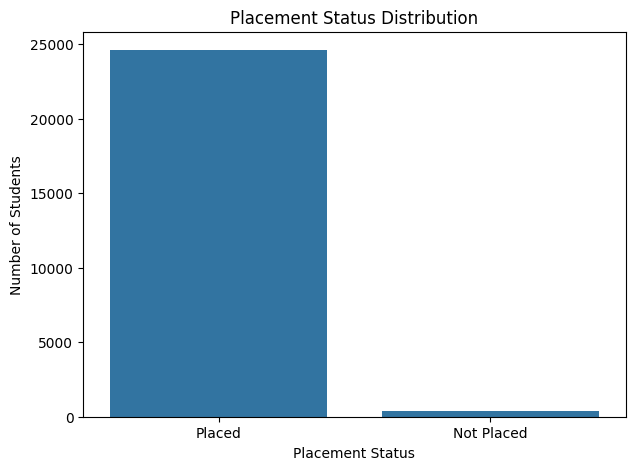

In [25]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="placement_status")

plt.title("Placement Status Distribution")
plt.xlabel("Placement Status")
plt.ylabel("Number of Students")
plt.show()

In [26]:
numeric_cols = [
    "age",
    "cgpa",
    "attendance_percentage",
    "DSA_problems_solved",
    "GitHub_repos",
    "hackathons_participated",
    "development_projects_count",
    "AI_ML_projects",
    "internships_completed",
    "resume_score",
    "communication_skills",
    "aptitude_score",
    "mock_interview_score"
]

print("Summary of Key Numerical Features:")
display(df[numeric_cols].describe().T)

Summary of Key Numerical Features:


,count,mean,std,min,25%,50%,75%,max
age,25000.0,22.507520,1.706898,20.0,21.00,22.00,24.00,25.0
cgpa,25000.0,7.460975,0.846094,5.0,6.89,7.46,8.03,10.0
attendance_percentage,25000.0,77.942360,9.956108,45.0,71.20,78.00,84.90,100.0
DSA_problems_solved,25000.0,646.777800,124.989386,185.0,562.00,646.00,731.00,1163.0
GitHub_repos,24500.0,18.688490,9.219579,0.0,12.00,18.00,25.00,60.0
hackathons_participated,25000.0,2.612720,1.835709,0.0,1.00,3.00,4.00,10.0
development_projects_count,25000.0,6.396520,2.631921,1.0,5.00,6.00,8.00,18.0
AI_ML_projects,25000.0,2.750640,1.880989,0.0,1.00,3.00,4.00,11.0
internships_completed,25000.0,2.871280,1.712760,0.0,2.00,3.00,4.00,11.0
resume_score,25000.0,85.539760,14.799386,23.0,75.00,89.00,100.00,100.0


<Figure size 1200x800 with 0 Axes>

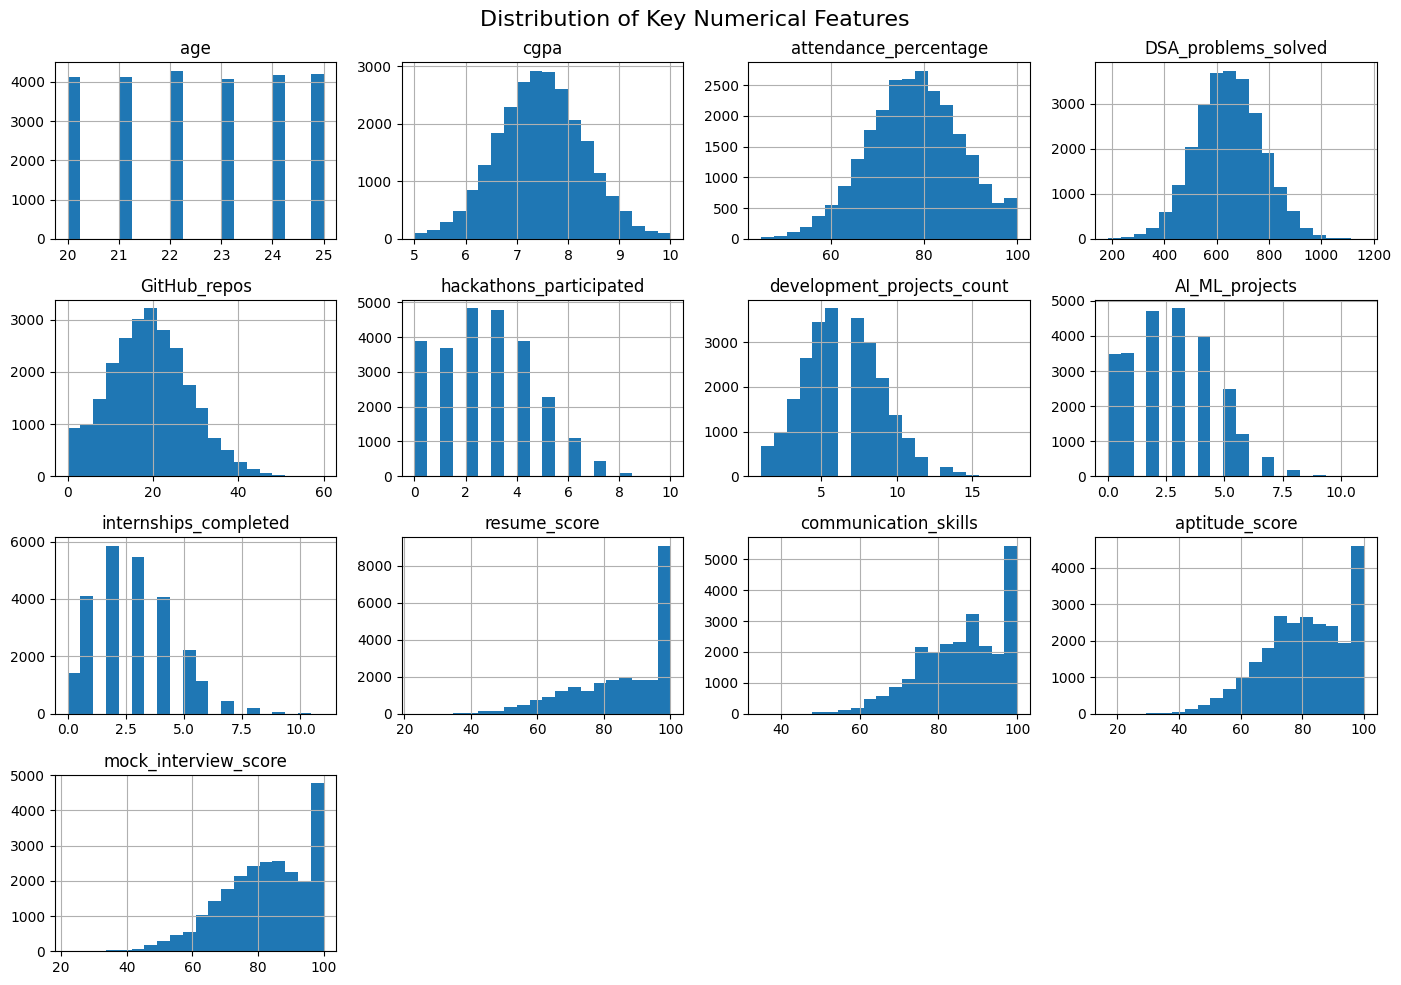

In [27]:
plt.figure(figsize=(12, 8))

df[numeric_cols].hist(figsize=(14, 10), bins=20)

plt.suptitle("Distribution of Key Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

In [28]:
placement_summary = df.groupby("placement_status")[numeric_cols].mean().round(2)

print("Average Feature Values by Placement Status:")
display(placement_summary)

Average Feature Values by Placement Status:


,age,cgpa,attendance_percentage,DSA_problems_solved,GitHub_repos,hackathons_participated,development_projects_count,AI_ML_projects,internships_completed,resume_score,communication_skills,aptitude_score,mock_interview_score
placement_status,,,,,,,,,,,,,
Not Placed,22.42,6.54,78.71,540.27,11.6,2.72,4.26,1.67,1.21,71.65,80.47,78.25,80.49
Placed,22.51,7.48,77.93,648.53,18.8,2.61,6.43,2.77,2.90,85.77,85.99,81.01,82.30


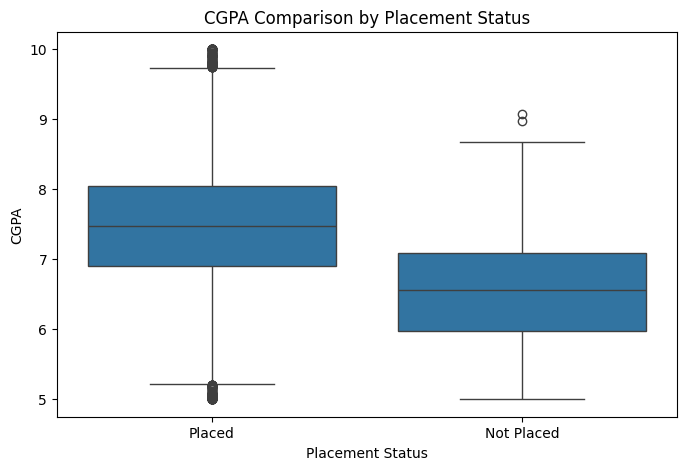

In [29]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="placement_status", y="cgpa")

plt.title("CGPA Comparison by Placement Status")
plt.xlabel("Placement Status")
plt.ylabel("CGPA")
plt.show()

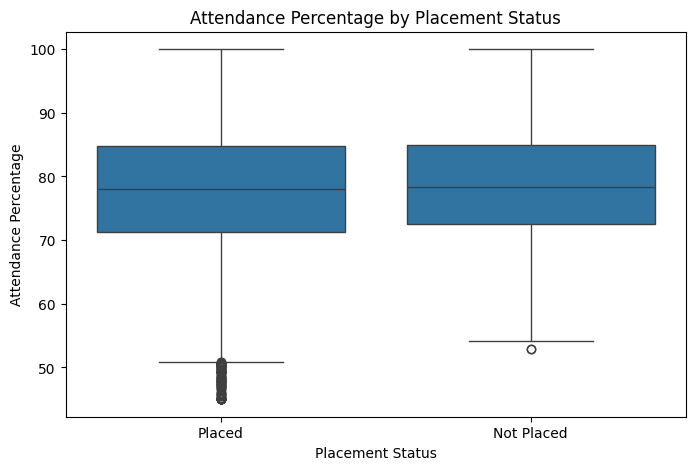

In [30]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="placement_status", y="attendance_percentage")

plt.title("Attendance Percentage by Placement Status")
plt.xlabel("Placement Status")
plt.ylabel("Attendance Percentage")
plt.show()

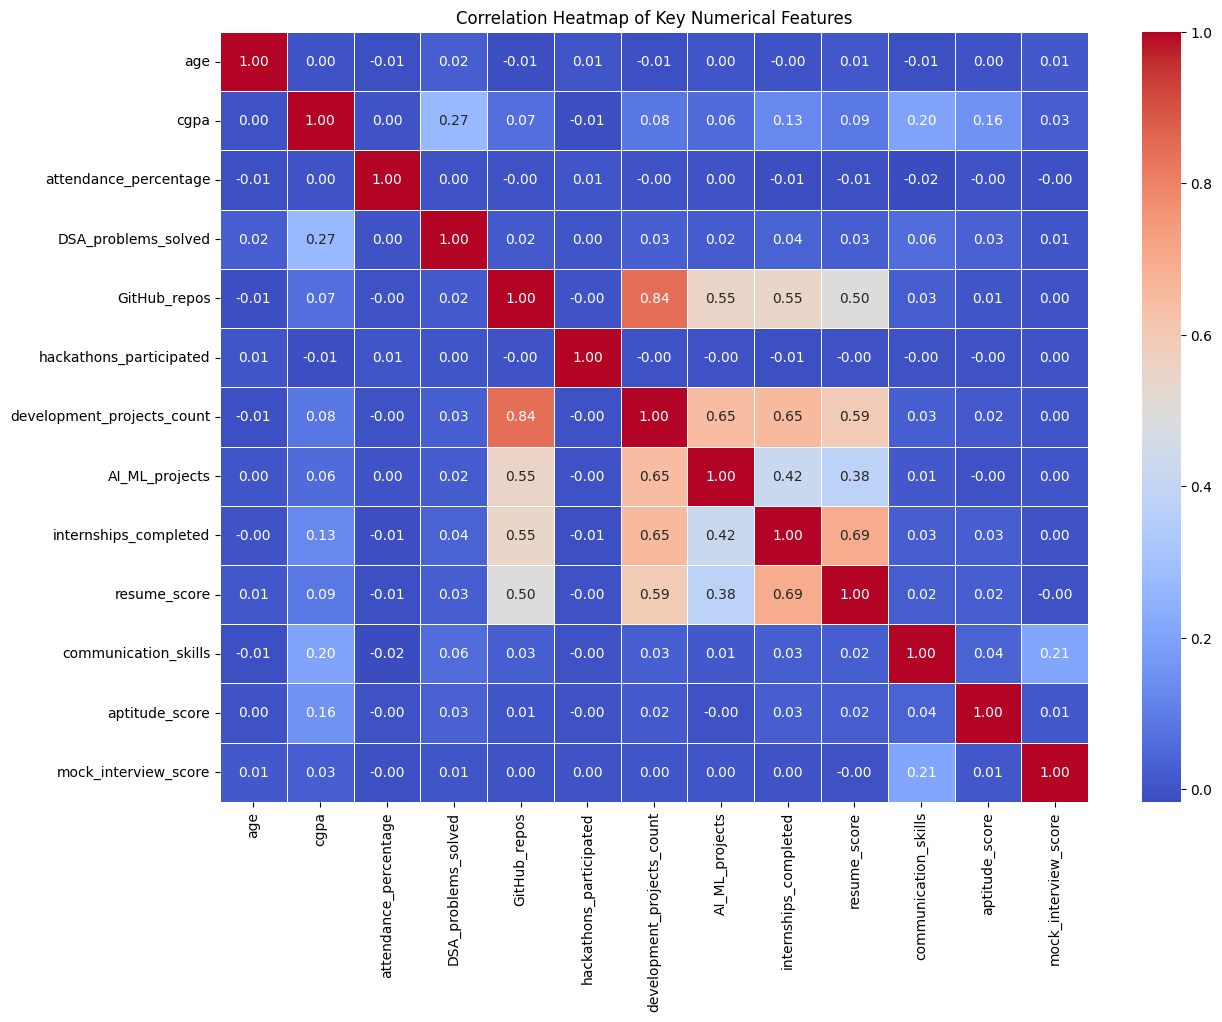

In [31]:
plt.figure(figsize=(14, 10))

correlation_matrix = df[numeric_cols].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Key Numerical Features")
plt.show()

In [32]:
X = df_model.drop(columns=["placement_status"])
y = df_model["placement_status"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nTarget values:")
print(y.value_counts())

Features shape: (25000, 36)
Target shape: (25000,)

Target values:
placement_status
Placed        24596
Not Placed      404
Name: count, dtype: int64


In [33]:
X = pd.get_dummies(X, drop_first=True)

print("Shape after encoding:", X.shape)
print("\nData types after encoding:")
print(X.dtypes.value_counts())

Shape after encoding: (25000, 52)

Data types after encoding:
int64      21
bool       21
float64    10
Name: count, dtype: int64


In [34]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaled feature matrix shape:", X_scaled.shape)
print("Scaling completed successfully.")

Scaled feature matrix shape: (25000, 52)
Scaling completed successfully.


In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training feature shape: (20000, 52)
Testing feature shape: (5000, 52)
Training target shape: (20000,)
Testing target shape: (5000,)


In [36]:
print("Total missing values in X:")
print(X.isnull().sum().sum())

print("\nColumns containing missing values:")
print(X.columns[X.isnull().any()].tolist())

Total missing values in X:
1500

Columns containing missing values:
['GitHub_repos', 'mock_interview_score', 'sleep_hours']


In [37]:
missing_cols = ["GitHub_repos", "mock_interview_score", "sleep_hours"]

for col in missing_cols:
    X[col] = X[col].fillna(X[col].median())

print("Missing values after imputation:")
print(X.isnull().sum().sum())

Missing values after imputation:
0


In [38]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaling completed successfully!")
print("Scaled feature matrix shape:", X_scaled.shape)

Scaling completed successfully!
Scaled feature matrix shape: (25000, 52)


In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training feature shape: (20000, 52)
Testing feature shape: (5000, 52)
Training target shape: (20000,)
Testing target shape: (5000,)


In [40]:
model = LogisticRegression(max_iter=1000, random_state=42)

model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [41]:
y_pred = model.predict(X_test)

print("Predictions generated successfully!")
print("Number of predictions:", len(y_pred))

Predictions generated successfully!
Number of predictions: 5000


In [42]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Evaluation functions imported successfully!")

Evaluation functions imported successfully!


In [43]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label="Placed")
recall = recall_score(y_test, y_pred, pos_label="Placed")
f1 = f1_score(y_test, y_pred, pos_label="Placed")

print("Model Performance:")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

Model Performance:
Accuracy : 0.9848
Precision: 0.9869
Recall   : 0.9978
F1 Score : 0.9923


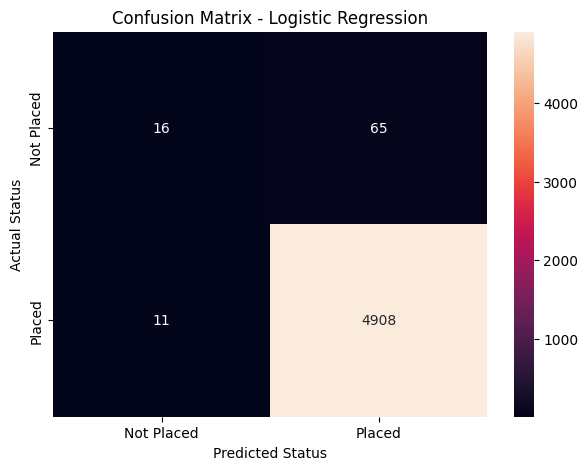

In [44]:
cm = confusion_matrix(y_test, y_pred, labels=["Not Placed", "Placed"])

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Not Placed", "Placed"],
    yticklabels=["Not Placed", "Placed"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Status")
plt.ylabel("Actual Status")
plt.show()

In [45]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

  Not Placed       0.59      0.20      0.30        81
      Placed       0.99      1.00      0.99      4919

    accuracy                           0.98      5000
   macro avg       0.79      0.60      0.64      5000
weighted avg       0.98      0.98      0.98      5000



In [46]:
cluster_cols = [
    "cgpa",
    "attendance_percentage",
    "DSA_problems_solved",
    "GitHub_repos",
    "hackathons_participated",
    "development_projects_count",
    "AI_ML_projects",
    "internships_completed",
    "resume_score",
    "communication_skills",
    "aptitude_score",
    "mock_interview_score"
]

cluster_data = df[cluster_cols].copy()

cluster_data = cluster_data.fillna(cluster_data.median())

cluster_scaled = StandardScaler().fit_transform(cluster_data)

print("Clustering data prepared successfully!")
print("Clustering feature shape:", cluster_scaled.shape)

Clustering data prepared successfully!
Clustering feature shape: (25000, 12)


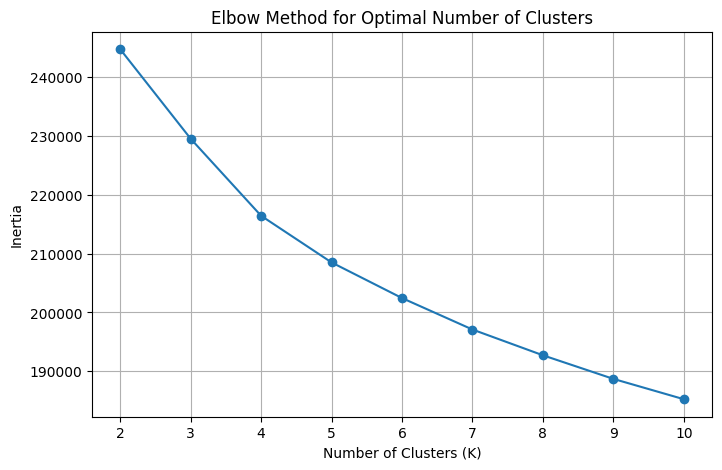

In [47]:
inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(cluster_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))

plt.plot(range(2, 11), inertia, marker="o")

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(range(2, 11))
plt.grid(True)
plt.show()

In [48]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(cluster_scaled)

df["cluster"] = cluster_labels

print("K-Means clustering completed successfully!")
print("\nNumber of students in each cluster:")
print(df["cluster"].value_counts().sort_index())

K-Means clustering completed successfully!

Number of students in each cluster:
cluster
0    5593
1    4116
2    4629
3    5996
4    4666
Name: count, dtype: int64


In [49]:
cluster_summary = df.groupby("cluster")[cluster_cols].mean().round(2)

print("Cluster Profile Summary:")
display(cluster_summary)

Cluster Profile Summary:


,cgpa,attendance_percentage,DSA_problems_solved,GitHub_repos,hackathons_participated,development_projects_count,AI_ML_projects,internships_completed,resume_score,communication_skills,aptitude_score,mock_interview_score
cluster,,,,,,,,,,,,
0,8.10,77.80,722.21,18.08,2.68,6.29,2.55,2.91,89.41,91.72,86.16,86.07
1,7.17,78.69,633.71,17.08,2.58,5.94,2.42,2.63,86.69,74.31,81.37,68.09
2,6.88,77.28,560.12,20.84,2.64,6.99,3.12,2.99,90.41,87.91,73.90,88.16
3,7.33,77.90,638.25,9.60,2.61,3.54,1.25,1.24,67.27,86.66,80.25,84.30
4,7.70,78.17,664.82,30.31,2.53,10.00,4.84,5.02,98.53,86.20,82.28,81.83


In [50]:
silhouette = silhouette_score(cluster_scaled, cluster_labels)

print("Silhouette Score:", round(silhouette, 4))

Silhouette Score: 0.0909


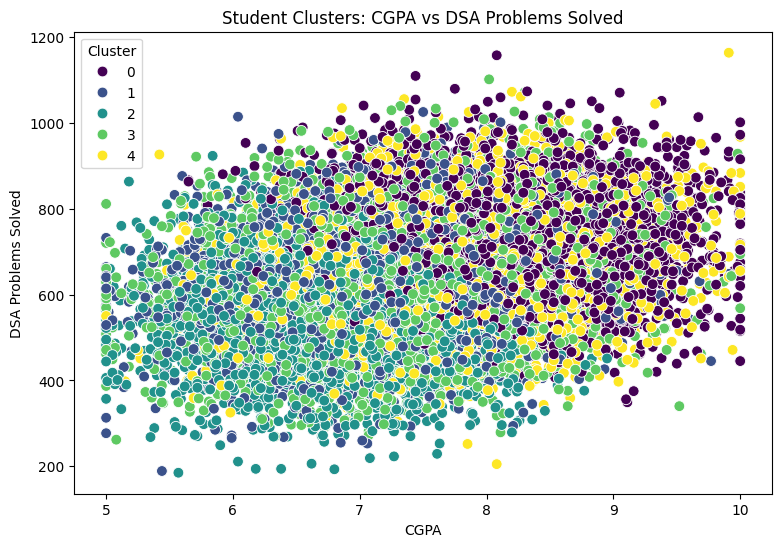

In [51]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="cgpa",
    y="DSA_problems_solved",
    hue="cluster",
    palette="viridis",
    s=60
)

plt.title("Student Clusters: CGPA vs DSA Problems Solved")
plt.xlabel("CGPA")
plt.ylabel("DSA Problems Solved")
plt.legend(title="Cluster")
plt.show()

In [52]:
cluster_placement = pd.crosstab(
    df["cluster"],
    df["placement_status"],
    normalize="index"
) * 100

cluster_placement = cluster_placement.round(2)

print("Placement Percentage by Cluster:")
display(cluster_placement)

Placement Percentage by Cluster:


placement_status,Not Placed,Placed
cluster,,
0,0.05,99.95
1,2.09,97.91
2,1.51,98.49
3,4.05,95.95
4,0.04,99.96


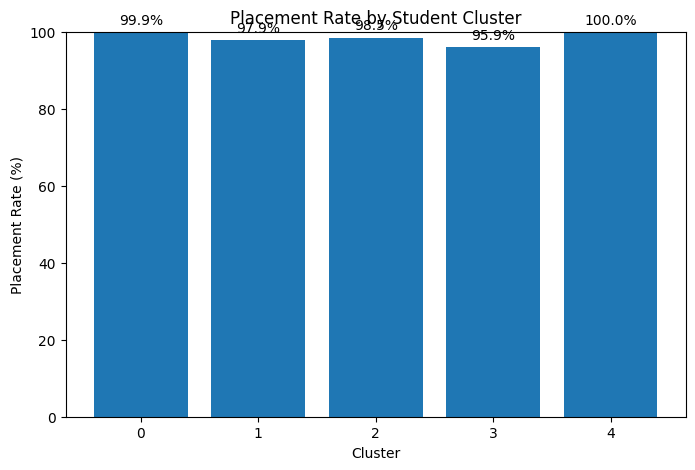

In [53]:
placed_rate = (
    df.assign(placed=df["placement_status"] == "Placed")
      .groupby("cluster")["placed"]
      .mean() * 100
)

plt.figure(figsize=(8, 5))

plt.bar(placed_rate.index.astype(str), placed_rate.values)

plt.title("Placement Rate by Student Cluster")
plt.xlabel("Cluster")
plt.ylabel("Placement Rate (%)")
plt.ylim(0, 100)

for i, value in enumerate(placed_rate.values):
    plt.text(i, value + 2, f"{value:.1f}%", ha="center")

plt.show()

In [54]:
print("===== FINAL PROJECT RESULTS =====")

print("\nSUPERVISED LEARNING - LOGISTIC REGRESSION")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

print("\nUNSUPERVISED LEARNING - K-MEANS")
print("Number of Clusters:", 5)
print("Silhouette Score:", round(silhouette, 4))

print("\nPROJECT PIPELINE COMPLETED SUCCESSFULLY!")

===== FINAL PROJECT RESULTS =====

SUPERVISED LEARNING - LOGISTIC REGRESSION
Accuracy : 0.9848
Precision: 0.9869
Recall   : 0.9978
F1 Score : 0.9923

UNSUPERVISED LEARNING - K-MEANS
Number of Clusters: 5
Silhouette Score: 0.0909

PROJECT PIPELINE COMPLETED SUCCESSFULLY!


In [55]:
highest_cluster = placed_rate.idxmax()
lowest_cluster = placed_rate.idxmin()

print("===== KEY INSIGHTS =====")

print(
    f"Cluster {highest_cluster} has the highest placement rate "
    f"of {placed_rate[highest_cluster]:.2f}%."
)

print(
    f"Cluster {lowest_cluster} has the lowest placement rate "
    f"of {placed_rate[lowest_cluster]:.2f}%."
)

print("\nThe clustering analysis helps identify groups of students")
print("with different academic and career-readiness characteristics.")

===== KEY INSIGHTS =====
Cluster 4 has the highest placement rate of 99.96%.
Cluster 3 has the lowest placement rate of 95.95%.

The clustering analysis helps identify groups of students
with different academic and career-readiness characteristics.
